# Covertype - Exploratory Data Analysis

Perform an exploratory data analysis over the dataset `Covertype` in order to uncover patterns & distribution for guiding subsequent modeling steps.

# Setup Notebook

## Imports

In [14]:
# Import Standard Libraries
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.gridspec import GridSpec
from colorama import Style, Fore
from dotenv import load_dotenv
from pathlib import Path
from dynaconf import Dynaconf


## Setup Plot Characteristics

In [2]:
# Define Seaborn theme parameters
theme_parameters = {
    "axes.spines.right": False,
    "axes.spines.top": False,
    "grid.alpha": 0.3,
    "figure.figsize": (16, 6),
    "font.family": "Andale Mono",
    "axes.titlesize": 24,
    "figure.facecolor": "#E5E8E8",
    "axes.facecolor": "#E5E8E8",
}

# Set the theme
sns.set_theme(style="whitegrid", palette=sns.color_palette("deep"), rc=theme_parameters)

# Define Colors
black = Style.BRIGHT + Fore.BLACK
magenta = Style.BRIGHT + Fore.MAGENTA
red = Style.BRIGHT + Fore.RED
blue = Style.BRIGHT + Fore.BLUE
reset_colors = Style.RESET_ALL

## Define Configurations

In [3]:
# Read .env file
load_dotenv()

# Setup root path
root_path = Path(os.getenv("DRUIDIC_GROVE_AI_ROOT_PATH"))

print(f"🛤️ Root path: {root_path}")

# Read configurations
config = Dynaconf(
    settings_files=[root_path / "configurations" / "covertype" / "eda_config.toml"]
)

# Read configurations - Data Sources
covertype_data_path = config["data_sources"]["covertype_data_path"]
covertype_columns = config["data_sources"]["covertype_columns"]

🛤️ Root path: /Users/simone.porreca/Projects/DruidicGroveAI


## Read Data

In [5]:
# Read data files
covertype_data = pd.read_csv(root_path / covertype_data_path)
covertype_data.columns = covertype_columns

# Exploratory Data Analysis

## General

In [10]:
covertype_data.info()
covertype_data.sample(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 581011 entries, 0 to 581010
Data columns (total 55 columns):
 #   Column                              Non-Null Count   Dtype
---  ------                              --------------   -----
 0   Elevation                           581011 non-null  int64
 1   Aspect                              581011 non-null  int64
 2   Slope                               581011 non-null  int64
 3   Horizontal_Distance_To_Hydrology    581011 non-null  int64
 4   Vertical_Distance_To_Hydrology      581011 non-null  int64
 5   Horizontal_Distance_To_Roadways     581011 non-null  int64
 6   Hillshade_9am                       581011 non-null  int64
 7   Hillshade_Noon                      581011 non-null  int64
 8   Hillshade_3pm                       581011 non-null  int64
 9   Horizontal_Distance_To_Fire_Points  581011 non-null  int64
 10  Wilderness_Area1                    581011 non-null  int64
 11  Soil_Type1                          581011 non-null 

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type,Wilderness_Area2,Wilderness_Area3,Wilderness_Area4
367782,2663,77,9,242,7,1761,232,223,122,1756,...,0,0,0,0,0,0,0,0,0,3
126061,3000,109,12,170,20,4607,241,226,113,42,...,0,0,0,0,0,0,0,0,0,2
525136,3214,9,11,510,131,3149,208,219,147,990,...,0,0,0,0,0,0,0,0,0,1
212099,3280,26,6,390,58,5392,217,227,146,457,...,0,0,0,0,0,0,1,0,0,1
337643,3325,37,17,459,91,1650,217,200,113,2190,...,0,0,0,0,0,0,0,1,0,1


In [11]:
print(f"{blue}Data Shapes:{blue}\n- All Data -> {red}{covertype_data.shape}\n")
print(
    f"{blue}Data Columns with Null Values:"
    f"{blue}\n- All Data -> {red}{covertype_data.isnull().any().sum()}\n"
)

Data Shapes:
- All Data -> (581011, 55)

Data Columns with Null Values:
- All Data -> 0



## Null Values

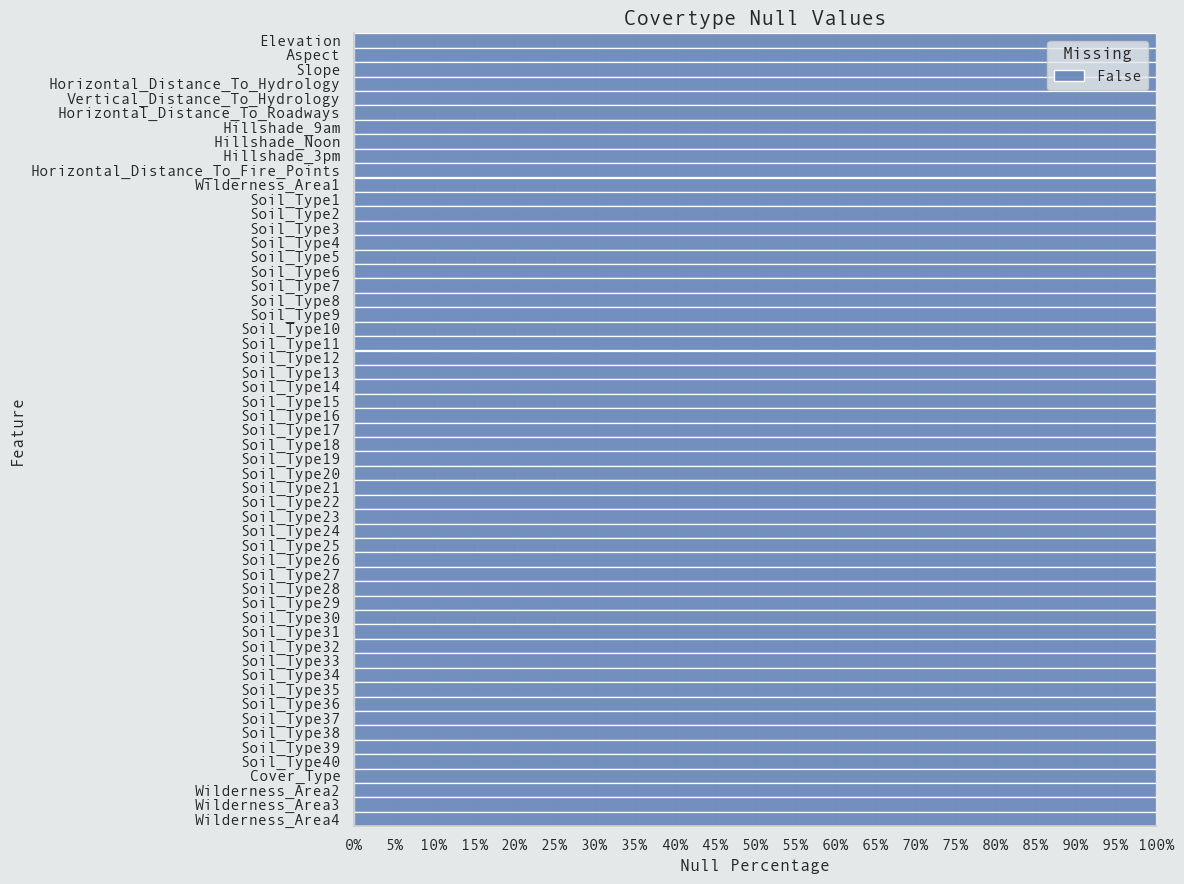

In [15]:
# Create figure
figure = plt.figure(tight_layout=True, figsize=(12, 9))

# Define figure's subplots
grid_spec = GridSpec(1, 1)

# Plot data
ax = figure.add_subplot(grid_spec[0, 0])

sns.histplot(
    data=covertype_data.isna().melt(var_name="Feature", value_name="Missing"),
    y="Feature",
    hue="Missing",
    multiple="fill",
    ax=ax,
)

# Refactor x label as missing percentage
ax.xaxis.set_major_locator(ticker.LinearLocator(21))
ax.xaxis.set_major_formatter("{:.0%}".format)

# Set title and label
ax.set_title("Covertype Null Values", fontsize=15)
ax.set_xlabel("Null Percentage")

plt.show()